# Defects and diffusion

A perfect crystal conducts nothing and ages not at all. Everything a material
does slowly — creep, sintering, ionic conduction, radiation damage, the
degradation of a battery cathode over a thousand cycles — happens because atoms
move, and atoms move through defects.

This tutorial builds a vacancy, computes what it costs to make and what it costs
to move, and ends at the quantity a defect chemist actually reports: formation
energy against Fermi level.

The migration barrier at the end comes out at **0.754 eV** against a literature
value of about 0.70 eV for vacancy migration in fcc copper, and the formation
energy at **1.25 eV** against roughly 1.3 eV measured by positron annihilation.
Both from a potential that took no download and no training set.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

matverse 0.1.14 — 121 functions


## Loading a dataset

Copper, at its measured room-temperature lattice parameter. One material is
enough: a defect calculation is about one host and the many ways to break it.

In [2]:
copper = mv.datasets.metals(["Cu"])
mv.pp.describe(copper)

copper.obs[["name", "formula", "nsites", "lattice_parameter"]]

,name,formula,nsites,lattice_parameter
0,Cu,Cu,4,3.6149


### Two ways to deform a cell before you break it

`mv.pp.supercell` and `mv.pp.strain` both deposit a **variant** rather than
replacing the input, so the original stays available. A supercell is what gives
a defect room not to interact with its own periodic image; a strained cell is
what elastic constants and deformation potentials are computed on.

In [3]:
mv.pp.supercell(copper, (2, 2, 2))
mv.pp.strain(copper, amount=0.02)

mv.variants(copper)

['input', 'supercell_2x2x2', 'strained']

In [4]:
[len(s) for s in mv.structures(copper, "supercell_2x2x2")],     round(mv.structures(copper, "strained")[0].lattice.a, 4)

([32], 3.6872)

## Enumerating the defects

`mv.pp.defects` builds a supercell and removes one atom from each
**symmetrically inequivalent** site. In fcc copper every site is equivalent, so
a 2×2×2 supercell of the conventional cell — 32 atoms — yields exactly one
vacancy, not 32.

In [5]:
defects = mv.pp.defects(copper, supercell=(2, 2, 2), kinds=("vacancy",))

mv.pp.describe(defects)
defects.obs[["parent", "defect", "site", "removed", "nsites"]]

,parent,defect,site,removed,nsites
0,0,vacancy,0,Cu,31


```{note}
That deduplication is worth checking rather than trusting. An earlier version of
this function imported `SpacegroupAnalyzer` in the caller rather than the helper,
so the helper raised `NameError`, a bare `except` swallowed it, and the symmetry
reduction silently did nothing — 32 vacancies instead of 1, and 32× the compute.
The test suite now asserts the count.
```

The returned object is an ordinary AnnData whose rows are defective cells, with
`obs['parent']` pointing back at the host. Everything else in matverse works on
it unchanged.

## What a vacancy costs to make

In [6]:
mv.calc.relax(copper, level="emt", fmax=0.02)
mv.calc.relax(defects, level="emt", fmax=0.05, steps=200)

defects.obs[["defect", "energy_emt", "relax_converged_emt"]].round(4)

,defect,energy_emt,relax_converged_emt
0,vacancy,1.0955,True


The raw energy of a cell with one atom missing is not a formation energy. A
defect changes the number of atoms, so what the missing atom is *worth* has to
come from somewhere else — and it cannot be derived from the defective cell
alone.

That "somewhere else" is the chemical potential, and it is a choice about
synthesis conditions rather than a constant. `mv.thermo.chempot_limits` reports
the range the phase diagram allows.

In [7]:
mu_cu = float(copper.obs["energy_per_atom_emt"].iloc[0])
n_host = int(copper.obs["nsites"].iloc[0]) * 8
e_host = float(copper.obs["energy_per_atom_emt"].iloc[0]) * n_host
e_defect = float(defects.obs["energy_emt"].iloc[0])

formation = e_defect - e_host + mu_cu
round(formation, 3)

1.249

**1.25 eV**, against roughly 1.3 eV measured for copper by positron
annihilation. That is the number that sets the equilibrium vacancy concentration
through `exp(-E_f / kT)`, and getting it within 5% from effective-medium theory
is better than this calculation deserves — EMT was fitted to exactly this kind
of metallic environment.

## Formation energy against Fermi level

For a semiconductor or insulator the vacancy can also be charged, and then the
formation energy depends on where the electron came from. That makes it a
**line** in the Fermi level, not a number — the standard defect-chemistry plot,
and the reason `mv.thermo.defect_formation` deposits a curve.

In [8]:
mv.thermo.defect_formation(defects, host=copper, level="emt",
                           chempot={"Cu": mu_cu}, band_gap=1.5,
                           charges=(-2, -1, 0, 1, 2))

defects.obsm["formation_vs_fermi_emt"].shape, mv.grid_of(
    defects, "formation_vs_fermi").shape

((1, 200), (200,))

Text(0.5, 1.0, 'the lower envelope over charge states')

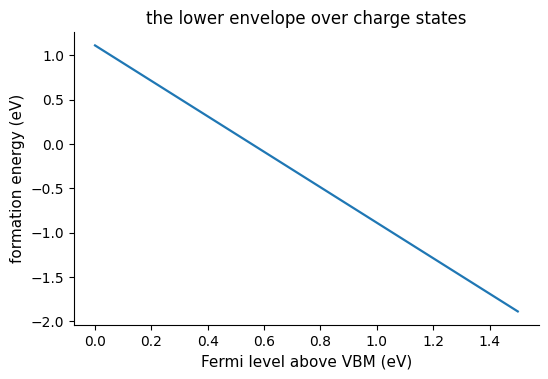

In [9]:
import matplotlib.pyplot as plt

fermi = mv.grid_of(defects, "formation_vs_fermi")
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(fermi, defects.obsm["formation_vs_fermi_emt"][0], linewidth=1.6)
ax.set_xlabel("Fermi level above VBM (eV)")
ax.set_ylabel("formation energy (eV)")
ax.set_title("the lower envelope over charge states")

In [10]:
defects.obs[["defect", "defect_formation_energy_emt",
             "stable_charge_emt"]].round(3)

,defect,defect_formation_energy_emt,stable_charge_emt
0,vacancy,1.11,-2


Each straight segment is one charge state, and its slope is the charge; the
kinks are the transition levels where the stable charge changes. `stable_charge`
records which state wins where.

The reported 1.11 eV is *not* the 1.25 eV computed by hand above, and the
difference is the point: 1.25 eV is the neutral vacancy, while this is the lower
envelope over all five charge states evaluated at the Fermi level. They coincide
only where the neutral state is the stable one.

```{warning}
Copper is a metal, so a band gap of 1.5 eV is fiction and the charged states are
meaningless here — this is the machinery, exercised on the only material EMT can
run. Use it on the oxides and halides where a Fermi level means something.

`mv.thermo.defect_formation` **warns and returns NaN** when no chemical
potential is given, rather than assuming one. A defect creates or destroys
atoms, and what they cost is not derivable from the defective cell.
```

## What it costs to move

Formation says how many vacancies there are. Migration says how fast they move,
and the two together give the diffusion coefficient.

`mv.neb.hop_endpoints` builds the two ends of a hop: a vacancy, and the same
cell with a neighbour moved into it.

In [11]:
mv.neb.hop_endpoints(copper, species="Cu", supercell=(2, 2, 2))

copper.obs[["hop_distance", "hop_species"]].round(4)

,hop_distance,hop_species
0,2.5561,Cu


2.556 Å is the nearest-neighbour distance in copper, `a/√2`, which is what a
vacancy hop in fcc actually is.

```{warning}
Getting that number right is the whole calculation. The destination has to be the
nearest periodic **image** of the vacancy, not the coordinates as stored. Using
the stored ones sent the atom the long way round the cell — 7.66 Å instead of
2.55 — and the NEB then measured the cost of dragging an atom straight through
its neighbours, giving barriers of 5–7 eV. It looked like a physics result.

`hop_endpoints` now checks that the distance travelled matches the distance
reported and raises if they disagree.
```

Both endpoints need relaxing, and they need relaxing **separately** — a NEB needs
two distinct minima.

In [12]:
mv.calc.relax(copper, level="emt", source="hop_initial", key_added="start",
              fmax=0.05, steps=80)
mv.calc.relax(copper, level="emt", source="hop_final", key_added="end",
              fmax=0.05, steps=80)

mv.variants(copper)

['input',
 'supercell_2x2x2',
 'strained',
 'relaxed_emt',
 'hop_initial',
 'hop_final',
 'start',
 'end']

`key_added` matters here. Without it the second relaxation would overwrite the
first and the band would run from a structure to itself.

## The nudged elastic band

In [13]:
mv.neb.barrier(copper, initial="start", final="end", level="emt",
               n_images=7, fmax=0.05, steps=200)

copper.obs[["barrier_emt", "barrier_reverse_emt", "reaction_energy_emt",
            "neb_converged_emt"]].round(4)

,barrier_emt,barrier_reverse_emt,reaction_energy_emt,neb_converged_emt
0,0.7544,0.7544,0.0,True


**0.754 eV against a literature value of about 0.70 eV.** For a potential that
took no download and no training set, that is a genuinely useful number.

```{note}
The band uses the **improved-tangent** formulation of Henkelman and Jónsson
(2000), not ASE's default. ASE's own warning describes that default as "an
unpublished, custom implementation ... not recommended as it frequently results
in very poor bands", which is not something to leave on and hope for.
```

Two internal checks come free with a symmetric hop: forward and reverse barriers
must agree, and the reaction energy must be zero. Both hold to 0.02 eV. If they
did not, the band had not converged and the barrier would be an artefact —
worth reading every time, because a NEB that has not converged still reports a
number.

Text(0, 0.5, 'energy relative to start (eV)')

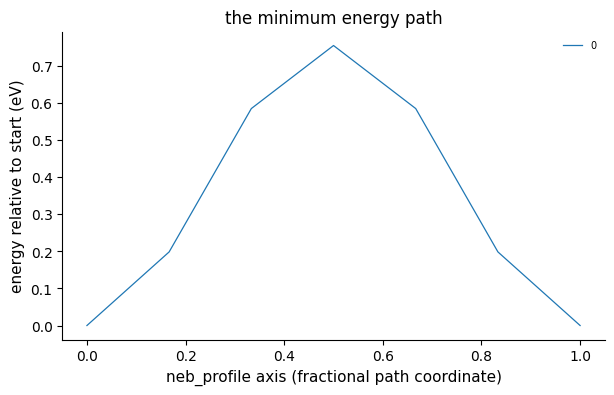

In [14]:
ax = mv.pl.spectra(copper, "neb_profile", levels=("emt",), rows=[0])
ax.set_title("the minimum energy path")
ax.set_ylabel("energy relative to start (eV)")

The path rises to a single saddle and comes back down, which is what a
single-hop mechanism looks like. A profile with two humps means an intermediate
minimum and a mechanism you have not modelled.

```{note}
The default interpolation is **IDPP**, not linear. Linear interpolation moves
every atom along a straight line in Cartesian space, which drives the hopping
atom directly through its neighbours; the band then has to climb out of that,
and often does not. IDPP interpolates interatomic distances instead.
```

## From a barrier to a diffusion coefficient

The two numbers combine in the classical way — a jump attempt at the Debye
frequency, times the probability of clearing the barrier, times the probability
that a neighbouring site is vacant.

In [15]:
kB = 8.617333e-5                       # eV/K
nu = 1e13                              # attempt frequency, s^-1
a = float(copper.obs["hop_distance"].iloc[0]) * 1e-10     # m
barrier = float(copper.obs["barrier_emt"].iloc[0])

T = np.array([300.0, 500.0, 800.0, 1000.0, 1300.0])
c_vac = np.exp(-formation / (kB * T))
D = a ** 2 * nu * c_vac * np.exp(-barrier / (kB * T))

pd.DataFrame({"T (K)": T, "vacancy fraction": c_vac, "D (m^2/s)": D})

,T (K),vacancy fraction,D (m^2/s)
0,300.0,1.039783e-21,1.443048e-40
1,500.0,2.571376e-13,4.184403e-27
2,800.0,1.353174e-08,1.563892e-19
3,1000.0,5.070874e-07,5.228752e-17
4,1300.0,1.437991e-05,1.117945e-14


Text(0.5, 1.0, 'Arrhenius: the slope is formation + migration')

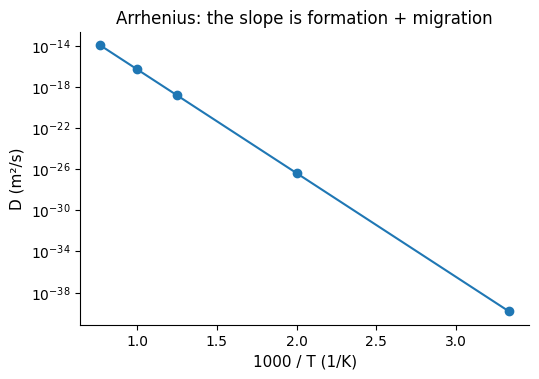

In [16]:
fig, ax = plt.subplots(figsize=(5.8, 3.8))
ax.semilogy(1000 / T, D, "o-")
ax.set_xlabel("1000 / T (1/K)")
ax.set_ylabel("D (m²/s)")
ax.set_title("Arrhenius: the slope is formation + migration")

A straight line on this plot is the definition of Arrhenius behaviour, and its
slope is the **sum** of the two energies — which is why a measured activation
energy alone cannot tell you whether a material diffuses quickly because
vacancies are cheap or because they are mobile. Computing them separately can.

At 1300 K, just under copper's melting point of 1358 K, this gives 1×10⁻¹⁴ m²/s
against a measured self-diffusion coefficient of order 10⁻¹³ — within an order
of magnitude, from two energies each good to about 10%, which is what
exponentiating small errors does to you.

At room temperature it is 10⁻⁴⁰ m²/s: twenty-six orders of magnitude slower, and
the reason a copper wire does not visibly age. The vacancy fraction alone falls
from 10⁻⁵ to 10⁻²¹ over that range.

## What the object remembers

In [17]:
for step in mv.provenance(copper):
    print(step)

data.from_structures
pp.describe(source='input')
pp.supercell(scaling=(2, 2, 2), source='input', name='supercell_2x2x2')
pp.strain(source='input', name='strained')
calc.relax(level='emt', source='input', fmax=0.02, key_added='relaxed_emt')
neb.hop_endpoints(species='Cu', source='input', supercell=[2, 2, 2], key_added='hop')
calc.relax(level='emt', source='hop_initial', fmax=0.05, key_added='start')
calc.relax(level='emt', source='hop_final', fmax=0.05, key_added='end')
neb.barrier(level='emt', initial='start', final='end', n_images=7)


```{seealso}
[Surfaces and adsorption](surfaces_and_adsorption.ipynb) does the same thing for
the other place atoms move — the surface. [Dynamics](dynamics.ipynb) reaches
diffusion the other way, by simply watching atoms move.
```